In [1]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import geneformer
import numpy as np
import pandas as pd
import transformers
import wandb
import scanpy as sc

import common_data
import geneformer_utils

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [4]:
mpl.rc_file_defaults()

In [23]:
api = wandb.Api()
entity, project = "serniczek", "serniczek"
runs = api.runs(entity + "/" + project)

entries = []
for run in runs:
    data = dict(
        name=run.name,
        group=run.group,
        state=run.state
    )
    # .summary contains output keys/values for
    # metrics such as accuracy.
    #  We call ._json_dict to omit large files
    data.update(run.summary._json_dict)
    data.update(run.config)

    # .name is the human-readable name of the run.
    entries.append(data)

runs_df = pd.DataFrame(entries)

In [24]:
# Remove in progress runs
runs_df = runs_df.loc[runs_df['train/train_runtime'].notna()]

In [25]:
runs_df.columns[runs_df.columns.str.startswith('eval/')]

Index(['eval/AUPRC', 'eval/AUROC', 'eval/accuracy', 'eval/f1_binary',
       'eval/loss', 'eval/precision', 'eval/recall', 'eval/runtime',
       'eval/samples_per_second', 'eval/steps_per_second',
       'eval/n_cells_class_0', 'eval/n_cells_class_1', 'eval/n_days_class_0',
       'eval/n_days_class_1'],
      dtype='object')

<Axes: ylabel='Frequency'>

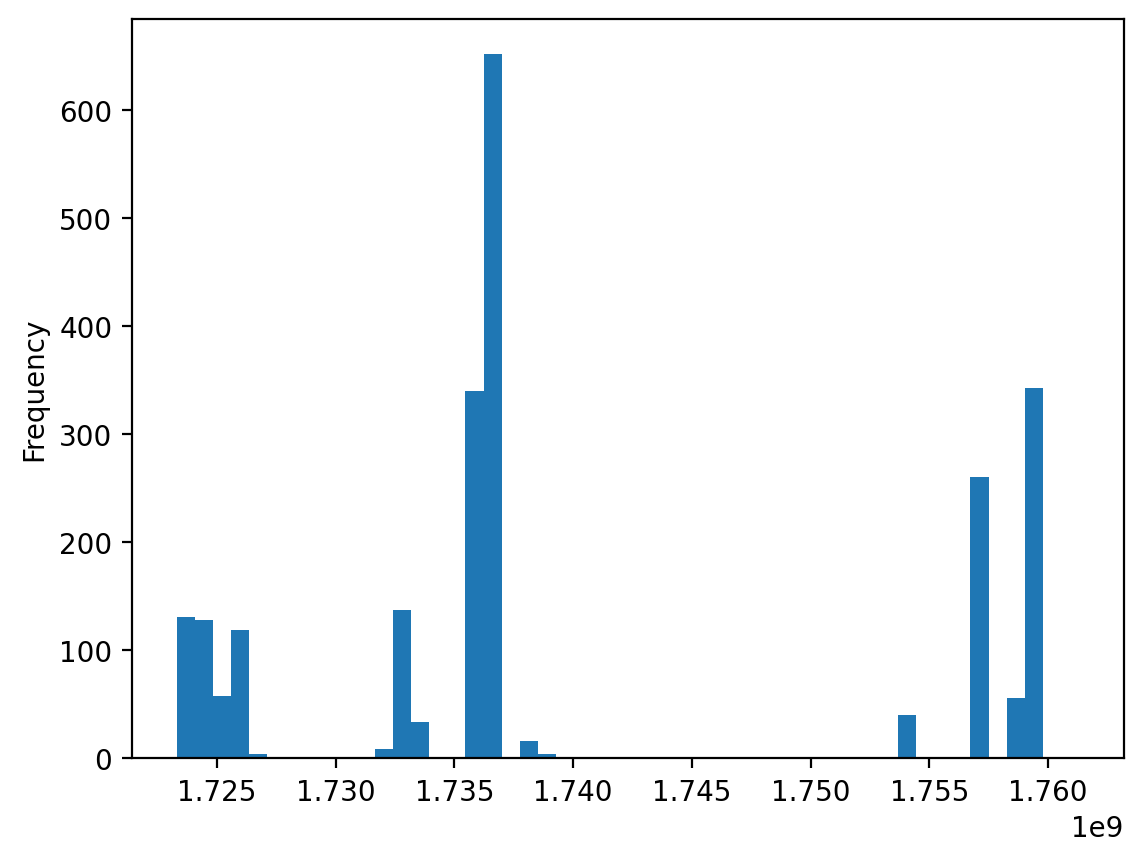

In [28]:
runs_df._timestamp.plot.hist(bins=50)

In [29]:
runs_df = runs_df.loc[runs_df._timestamp > 1.75e9]

In [31]:
runs_df = runs_df.loc[~runs_df.group.str.startswith('EHR')]

In [33]:
runs_df.shape

(400, 220)

In [34]:
runs_df = runs_df.sort_values(['group', 'name'])

In [35]:
runs_df.group = runs_df.group.str.replace(' aeruginosa', '')

In [36]:
runs_df._timestamp = runs_df._timestamp.apply(lambda x: datetime.datetime.fromtimestamp(x))

In [37]:
runs_df._timestamp = pd.to_datetime(runs_df._timestamp)

In [38]:
train_gens = runs_df.loc[:, 'bf16':'fsdp_transformer_layer_cls_to_wrap']

In [39]:
train_gens.shape

(400, 190)

In [ ]:
train_gens.drop(
    columns=[
        'output_dir', 'logging_dir', 'run_name', 'eval/n_cells_class_0', 'eval/n_cells_class_1',
        'train/n_cells_class_0', 'train/n_cells_class_1', 'fsdp', 'debug', 'report_to',
        'sharded_ddp', 'architectures', 'id2label',
        'label2id',
        'fsdp_config',
        'pruned_heads',
    ],
    inplace=True
)

In [41]:
train_gens = train_gens.drop_duplicates()

In [42]:
train_gens['_timestamp'] = runs_df._timestamp[train_gens.index]

In [43]:
train_gens = train_gens.sort_values('_timestamp').reset_index(drop=True)

In [44]:
to_keep = train_gens.columns[train_gens.nunique(dropna=False).gt(1)]

In [45]:
train_gens = train_gens[to_keep]

In [46]:
def set_train_gen(row):
    for i, train_gen in train_gens.iterrows():
        this_gen = True
        for c in train_gens.columns:
            if c == '_timestamp':
                continue
            if row[c] == train_gen[c] or (np.isnan(row[c]) and np.isnan(train_gen[c])):
                continue
            # print(f'Gen {i} not matching on {c}: {row[c]} vs {train_gen[c]}')
            this_gen = False
            break
        if this_gen:
            return i
    return -1

In [47]:
runs_df['train_gen'] = pd.Categorical(runs_df.apply(set_train_gen, axis=1))

In [48]:
runs_df.state.value_counts()

finished    400
Name: state, dtype: int64

In [49]:
runs_df = runs_df.loc[runs_df.state.eq('finished')].copy()

In [50]:
runs_df['split'] = runs_df.name.str.extract(r'(split_\d)')

Text(0.5, 1.0, 'eval/AUPRC')

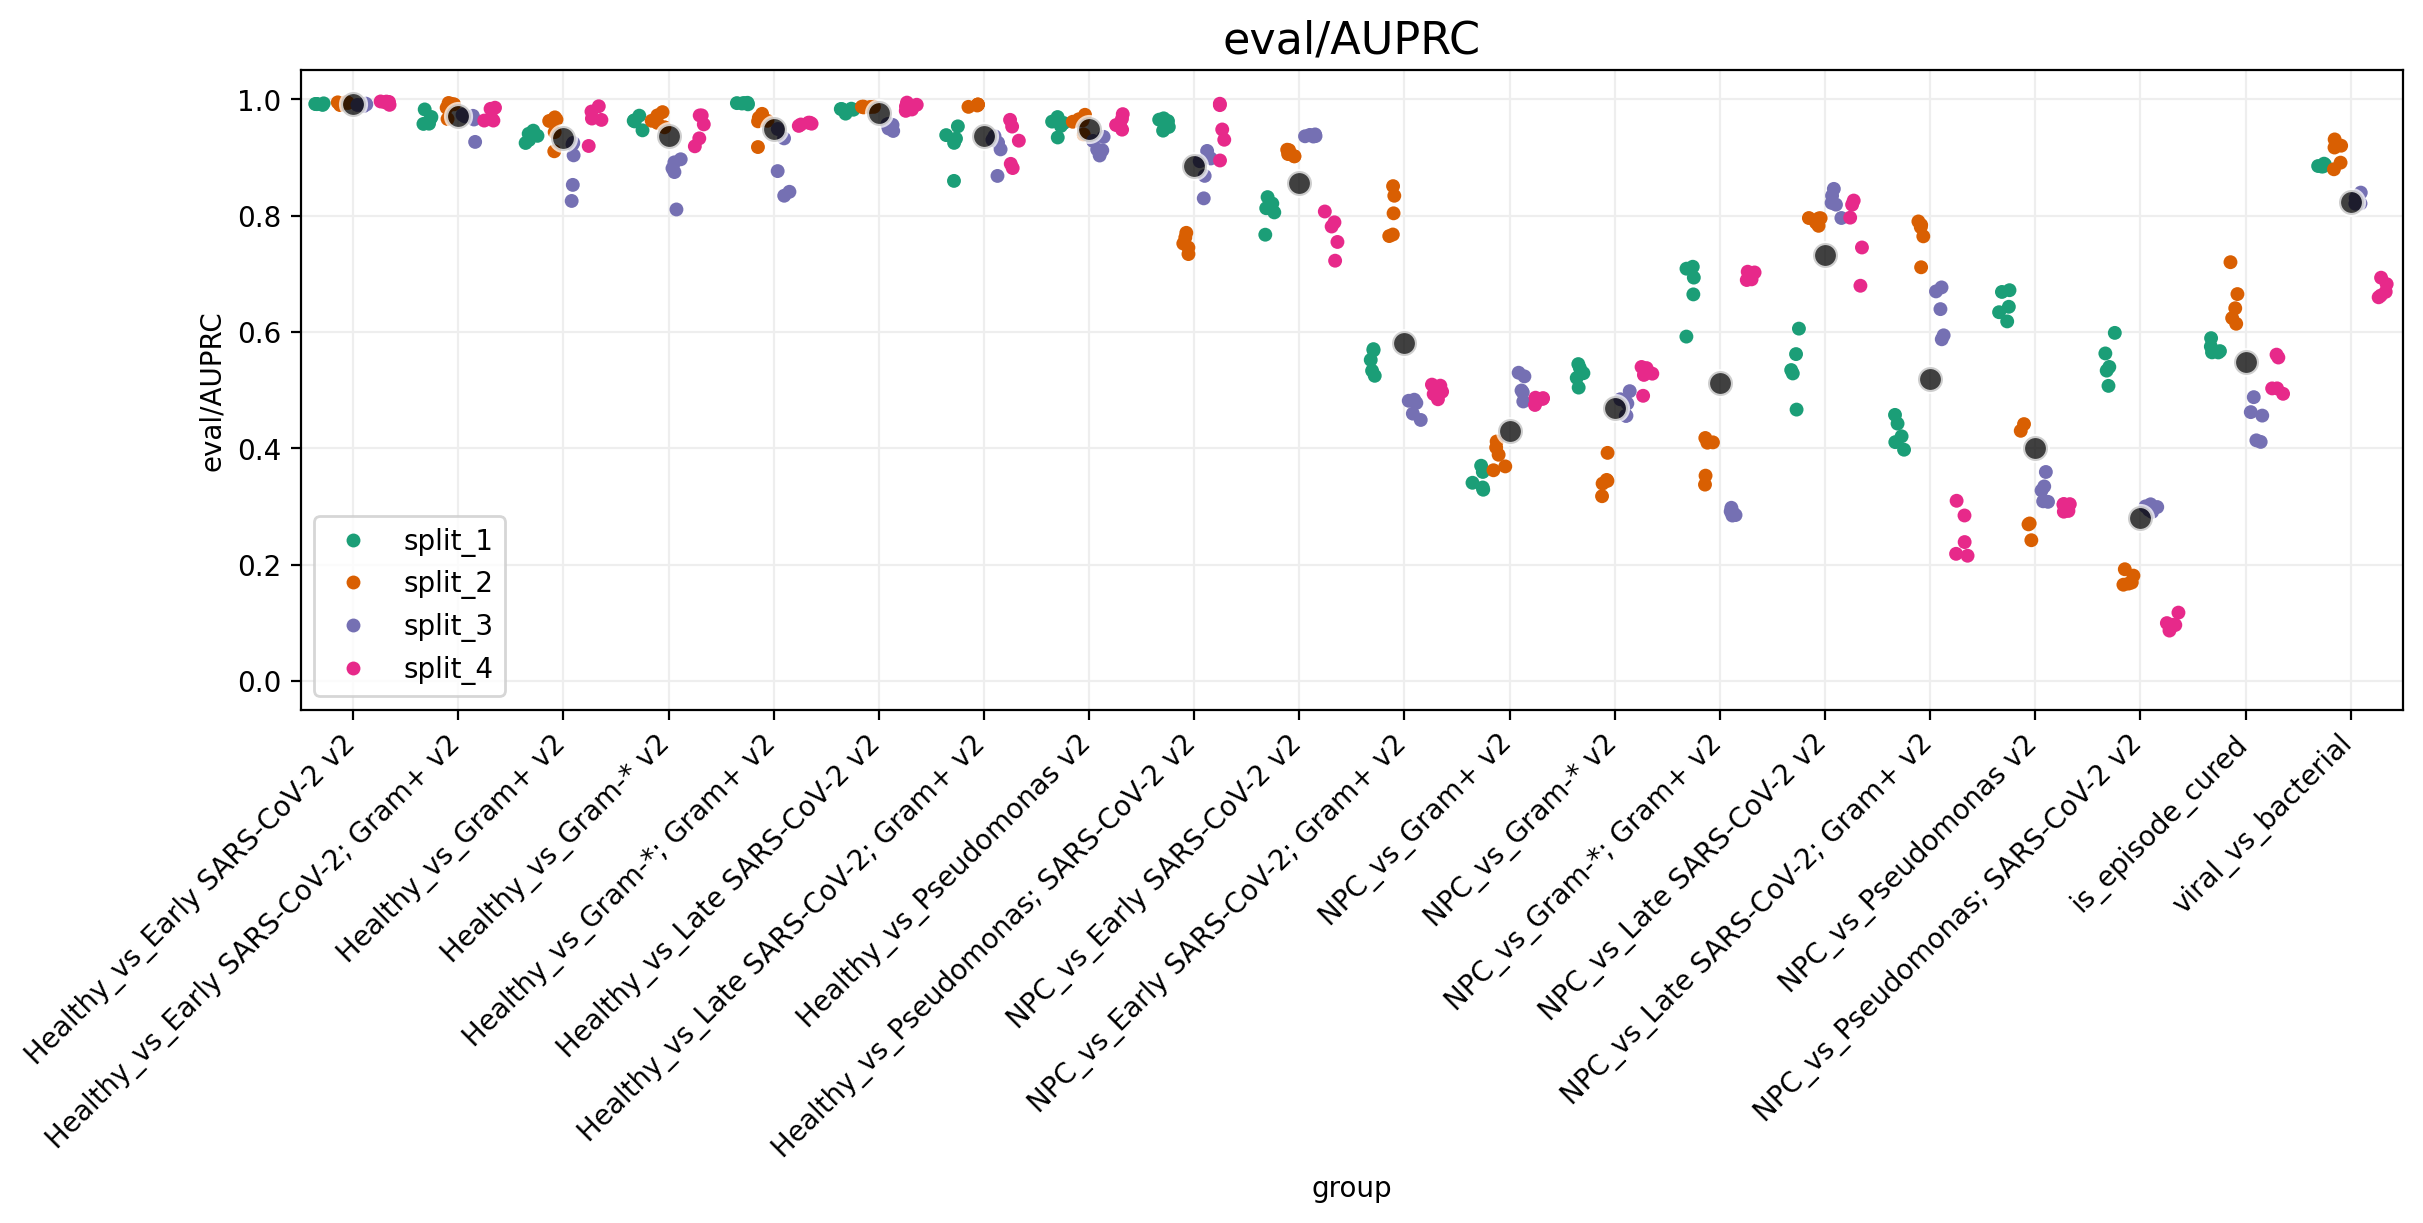

In [51]:
param = 'eval/AUPRC'
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.stripplot(
    data=runs_df,
    x='group',
    hue='split',
    dodge=True,
    y=param,
    ax=ax,
    size=5,
    jitter=0.25,
    palette='Dark2'
)
sns.stripplot(
    data=runs_df.groupby('group')[param].mean().reset_index(),
    x='group',
    y=param,
    ax=ax,
    size=9,
    edgecolor='white',
    linewidth=1.5,
    color='black',
    alpha=0.75
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.grid(color='#eee')
ax.set_ylim(-0.05, 1.05)
ax.set_title(param, size=16)

Text(0.5, 1.0, 'eval/AUROC')

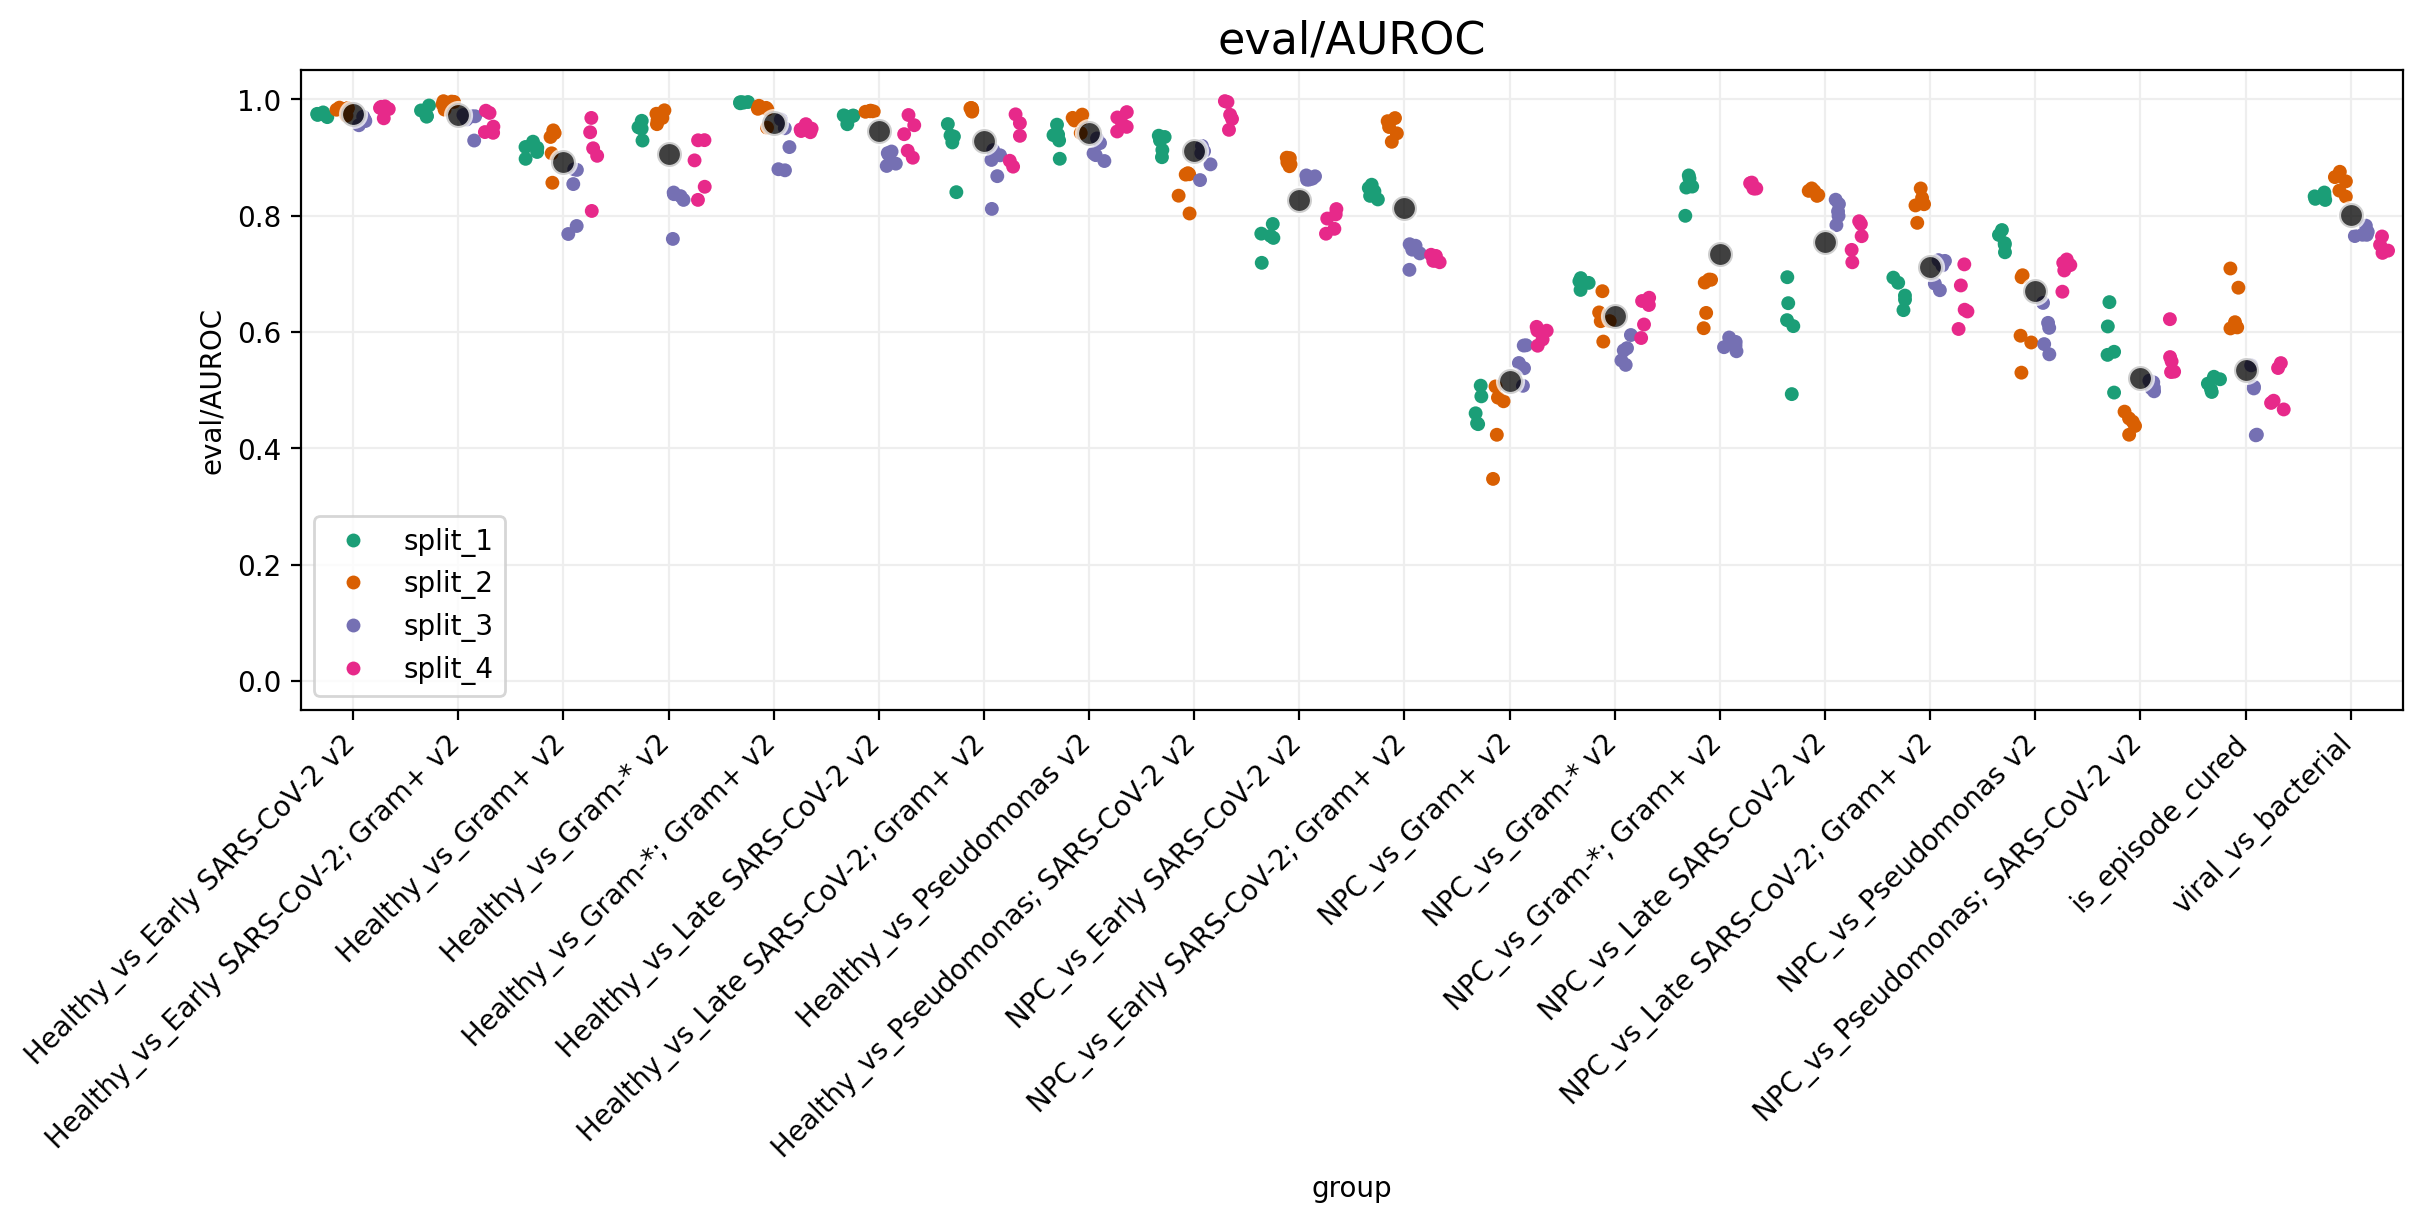

In [52]:
param = 'eval/AUROC'
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.stripplot(
    data=runs_df,
    x='group',
    hue='split',
    dodge=True,
    y=param,
    ax=ax,
    size=5,
    jitter=0.25,
    palette='Dark2'
)
sns.stripplot(
    data=runs_df.groupby('group')[param].mean().reset_index(),
    x='group',
    y=param,
    ax=ax,
    size=9,
    edgecolor='white',
    linewidth=1.5,
    color='black',
    alpha=0.75
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.grid(color='#eee')
ax.set_ylim(-0.05, 1.05)
ax.set_title(param, size=16)

Text(0.5, 1.0, 'train/global_step')

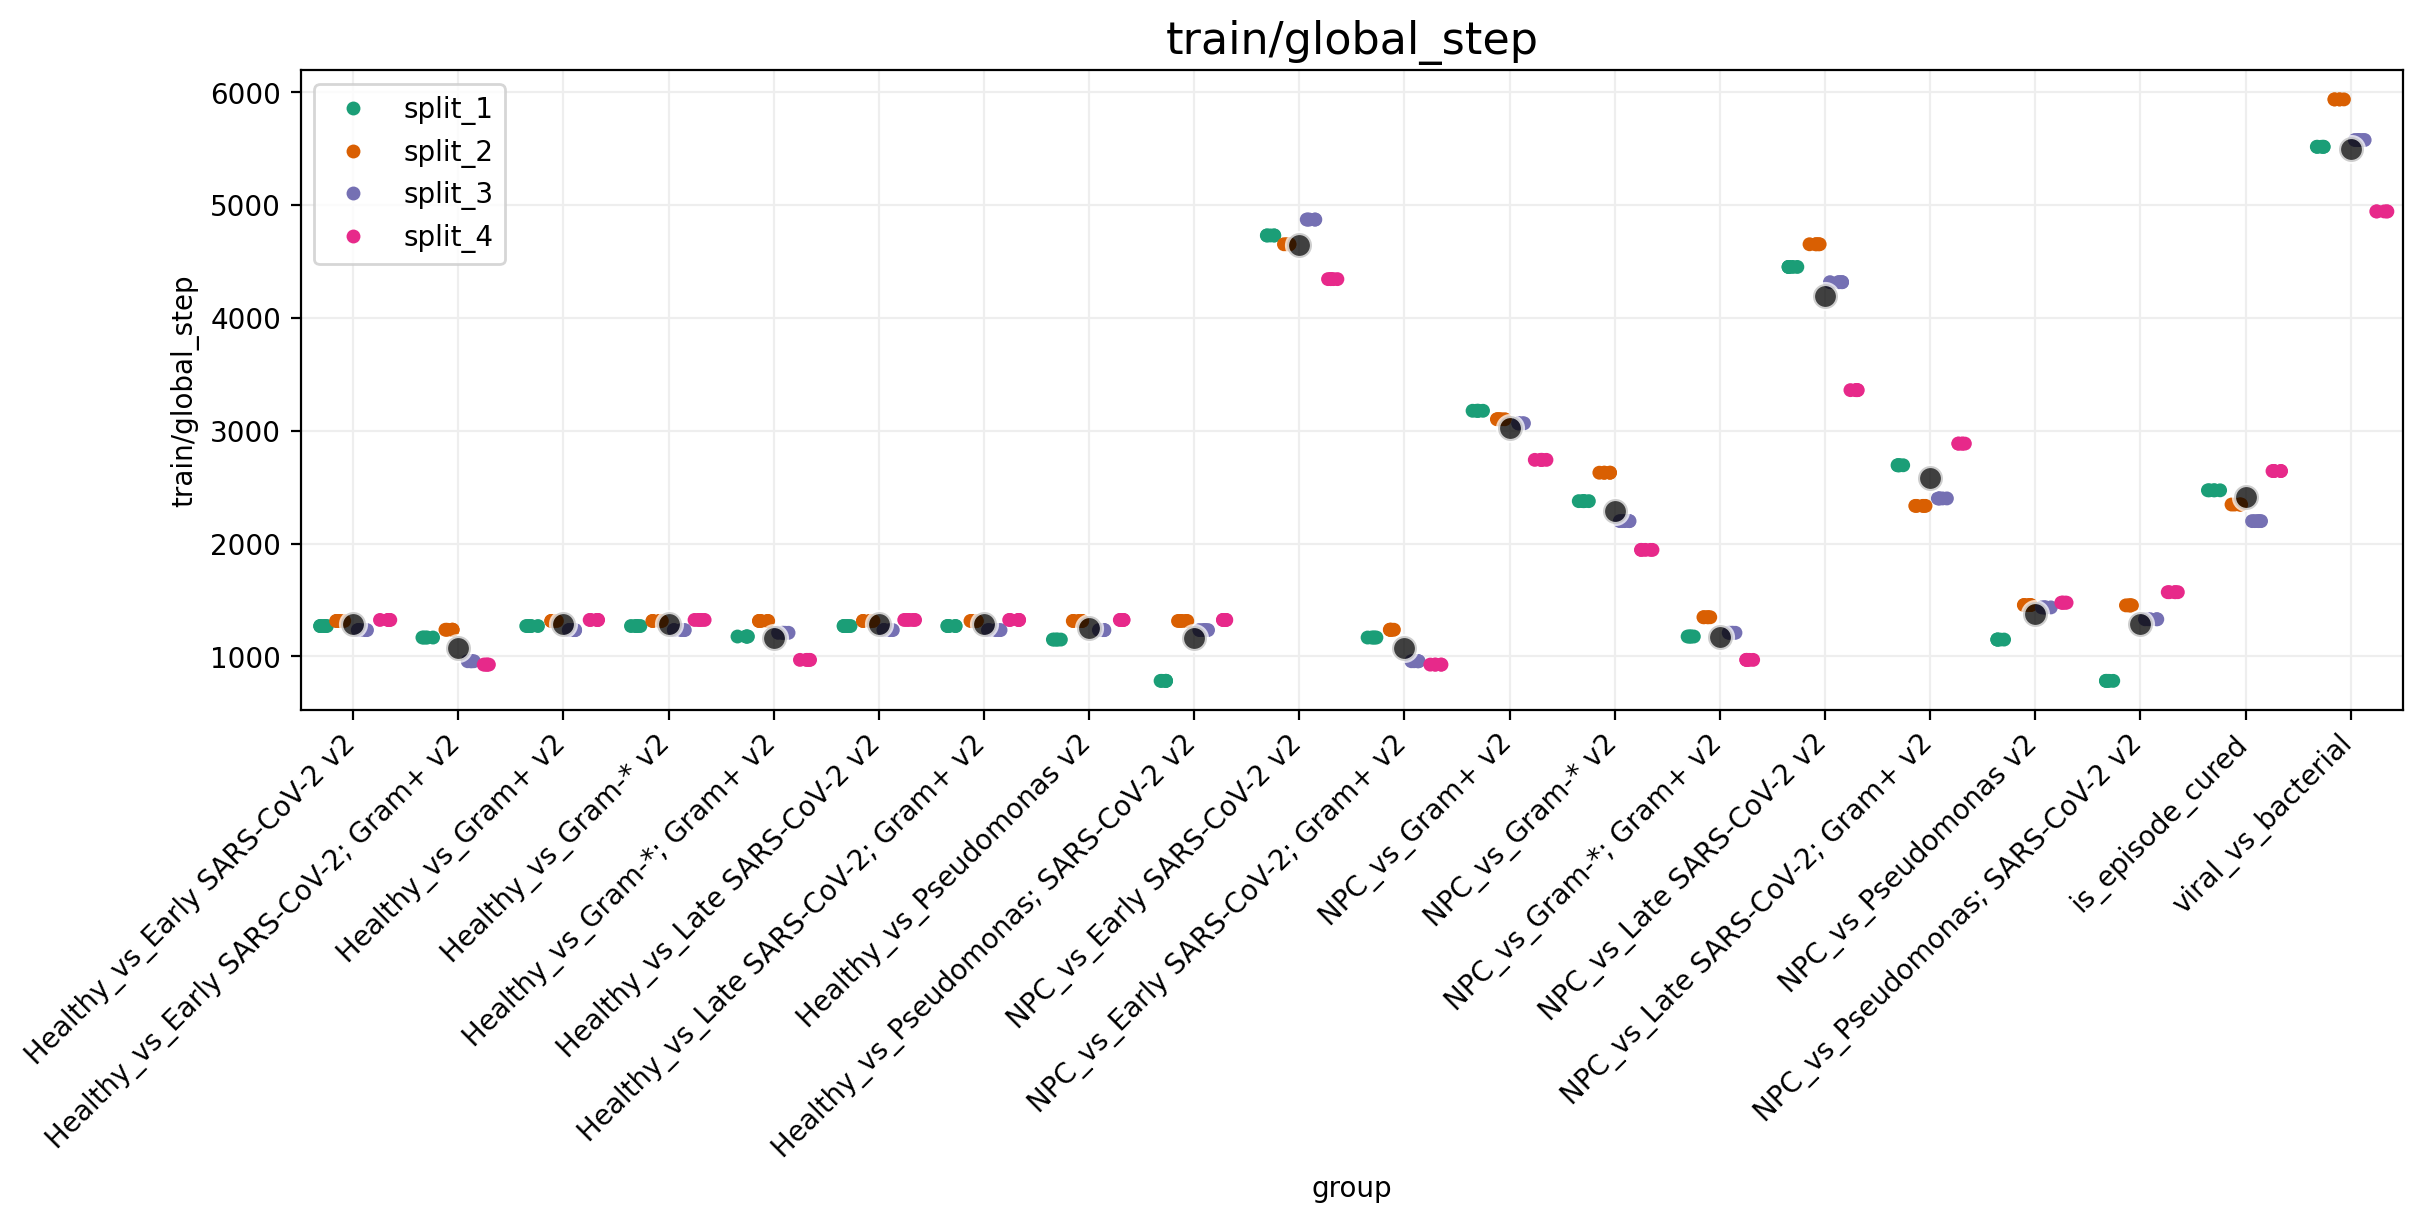

In [53]:
param = 'train/global_step'
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.stripplot(
    data=runs_df,
    x='group',
    hue='split',
    dodge=True,
    y=param,
    ax=ax,
    size=5,
    jitter=0.25,
    palette='Dark2'
)
sns.stripplot(
    data=runs_df.groupby('group')[param].mean().reset_index(),
    x='group',
    y=param,
    ax=ax,
    size=9,
    edgecolor='white',
    linewidth=1.5,
    color='black',
    alpha=0.75
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.grid(color='#eee')
ax.set_title(param, size=16)

Text(0.5, 1.0, 'eval/accuracy')

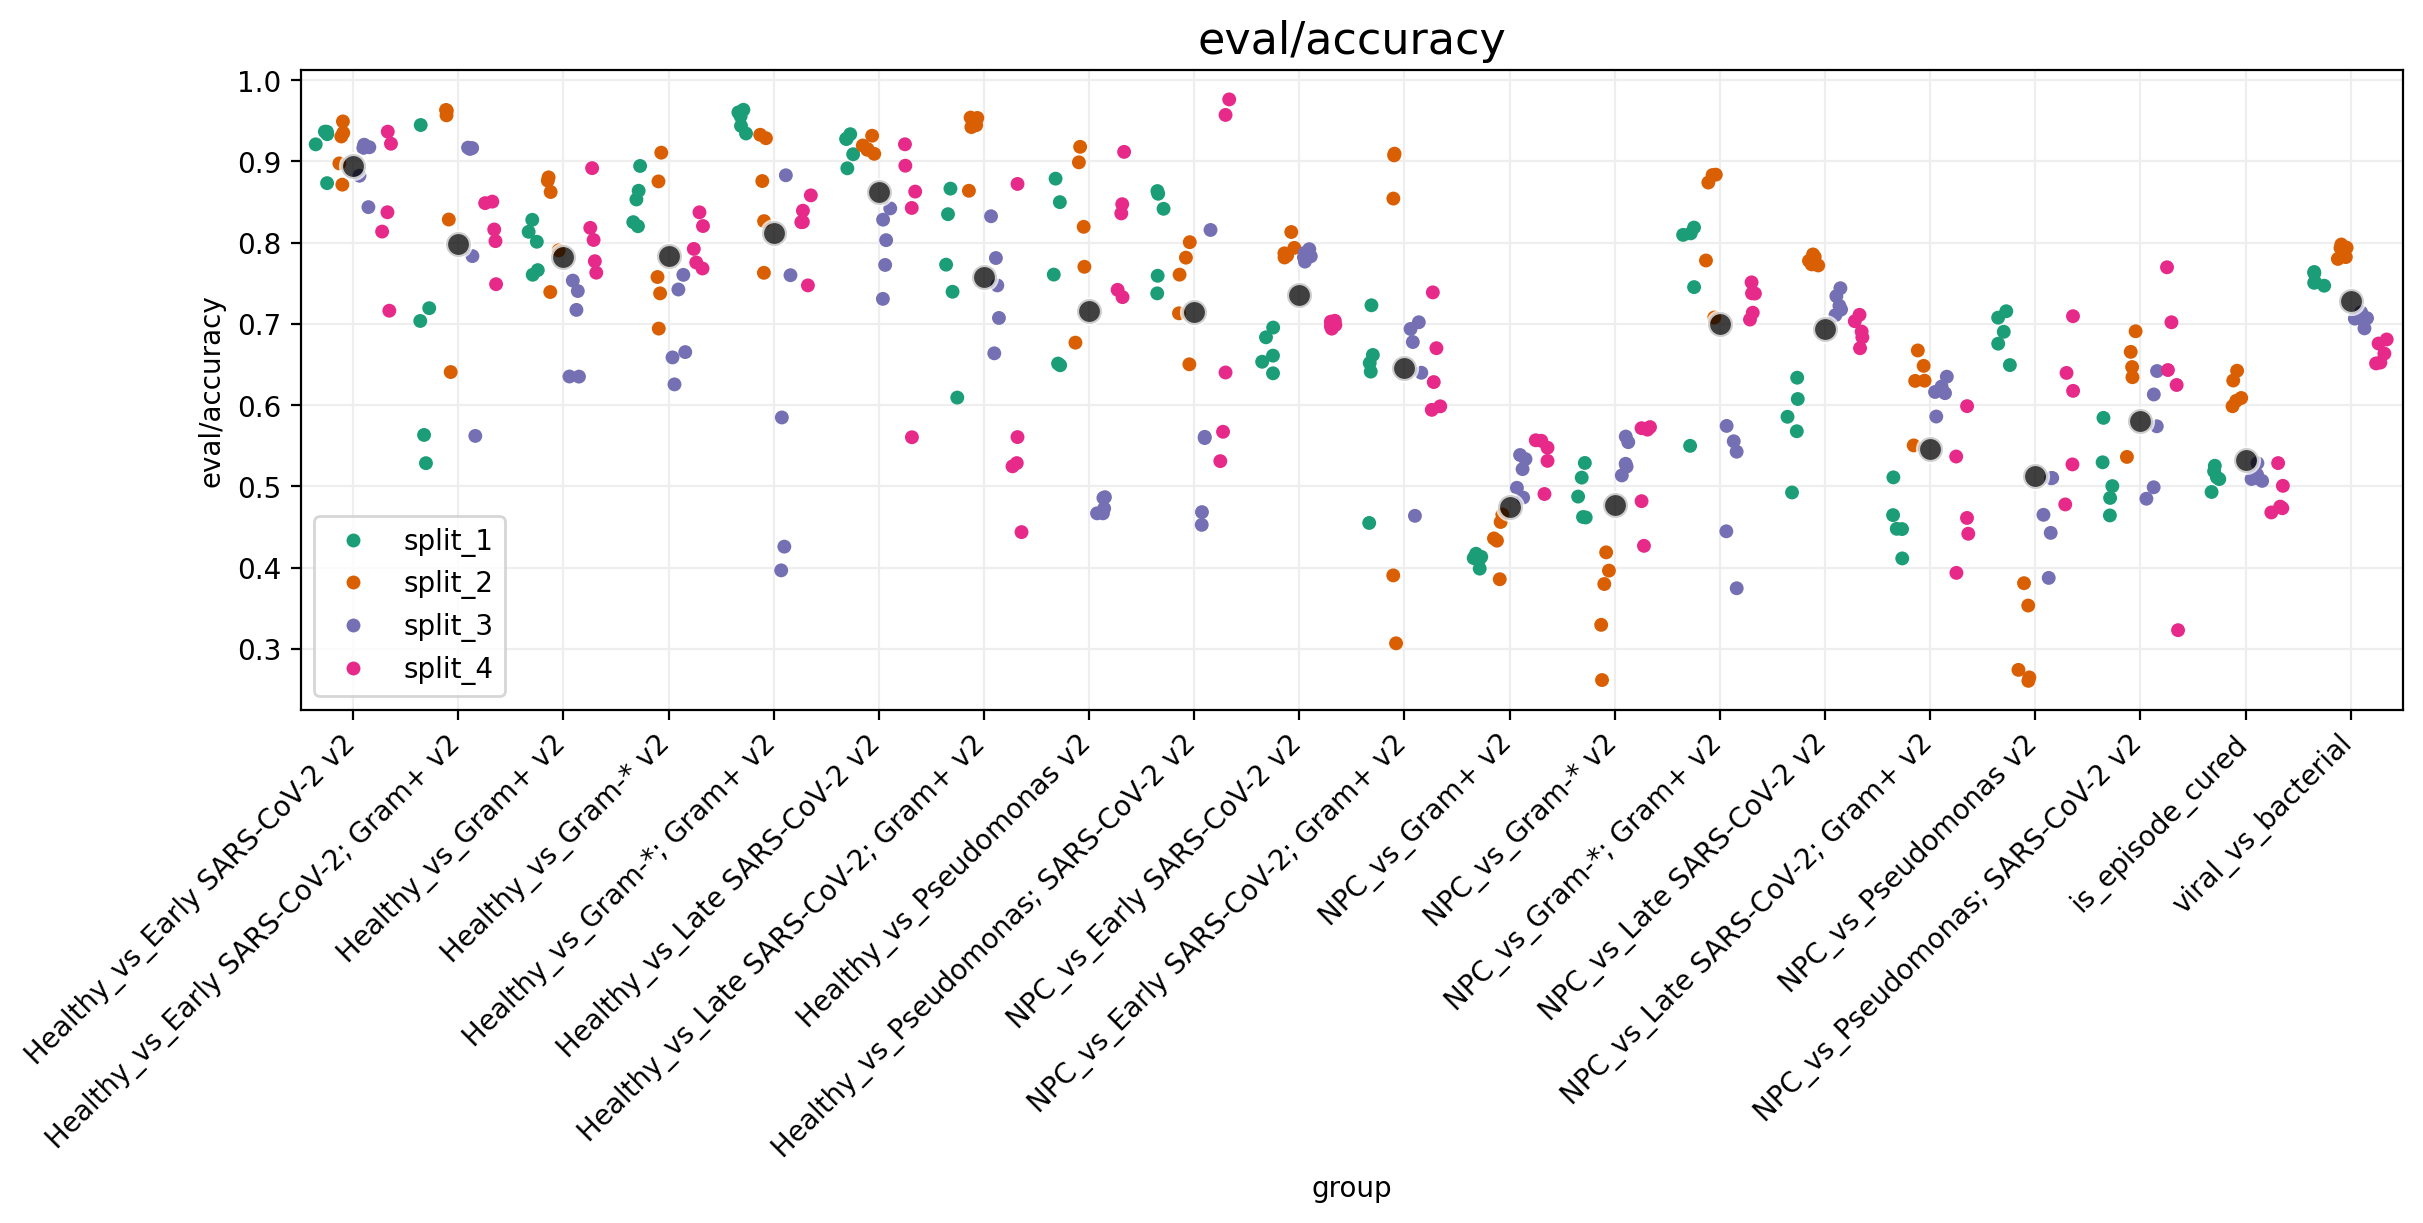

In [54]:
param = 'eval/accuracy'
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.stripplot(
    data=runs_df,
    x='group',
    hue='split',
    dodge=True,
    y=param,
    ax=ax,
    size=5,
    jitter=0.25,
    palette='Dark2'
)
sns.stripplot(
    data=runs_df.groupby('group')[param].mean().reset_index(),
    x='group',
    y=param,
    ax=ax,
    size=9,
    edgecolor='white',
    linewidth=1.5,
    color='black',
    alpha=0.75
)
trans = mpl.transforms.Affine2D().translate(8, 0)
for t in ax.get_xticklabels():
    t.set_ha('right')
    t.set_rotation(45)
    t.set_transform(t.get_transform() + trans)
ax.grid(color='#eee')
ax.set_title(param, size=16)

In [56]:
runs_df.loc[runs_df.group.eq('NPC_vs_Gram+ v2')][[
    'name', 'eval/AUPRC', 'eval/AUROC', 'eval/recall', 'eval/precision', 'train/global_step', 'train/epoch'
]]

,name,eval/AUPRC,eval/AUROC,eval/recall,eval/precision,train/global_step,train/epoch
225,NPC_vs_Gram+ v2_split_1_1,0.328727,0.441513,0.713612,0.366094,3177.0,3.0
233,NPC_vs_Gram+ v2_split_1_2,0.332553,0.442890,0.754265,0.362912,3177.0,3.0
161,NPC_vs_Gram+ v2_split_1_3,0.369973,0.507671,0.908240,0.386733,3177.0,3.0
114,NPC_vs_Gram+ v2_split_1_4,0.359300,0.489341,0.838258,0.378876,3177.0,3.0
92,NPC_vs_Gram+ v2_split_1_5,0.340666,0.460147,0.823448,0.376169,3177.0,3.0
11,NPC_vs_Gram+ v2_split_2_1,0.388857,0.480848,0.945871,0.405388,3102.0,3.0
260,NPC_vs_Gram+ v2_split_2_2,0.401325,0.487107,0.811054,0.407866,3102.0,3.0
242,NPC_vs_Gram+ v2_split_2_3,0.362194,0.347340,0.953008,0.384916,3102.0,3.0
168,NPC_vs_Gram+ v2_split_2_4,0.411677,0.506312,0.875709,0.408973,3102.0,3.0
121,NPC_vs_Gram+ v2_split_2_5,0.368828,0.423221,0.790393,0.389485,3102.0,3.0
